In [9]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
from torch import nn
import torchvision.transforms as T
import cv2 as cv
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR
import math
from os.path import isfile, join
from os import listdir

The very listed filename: 100__M_Left_index_finger.BMP


<Figure size 640x480 with 0 Axes>

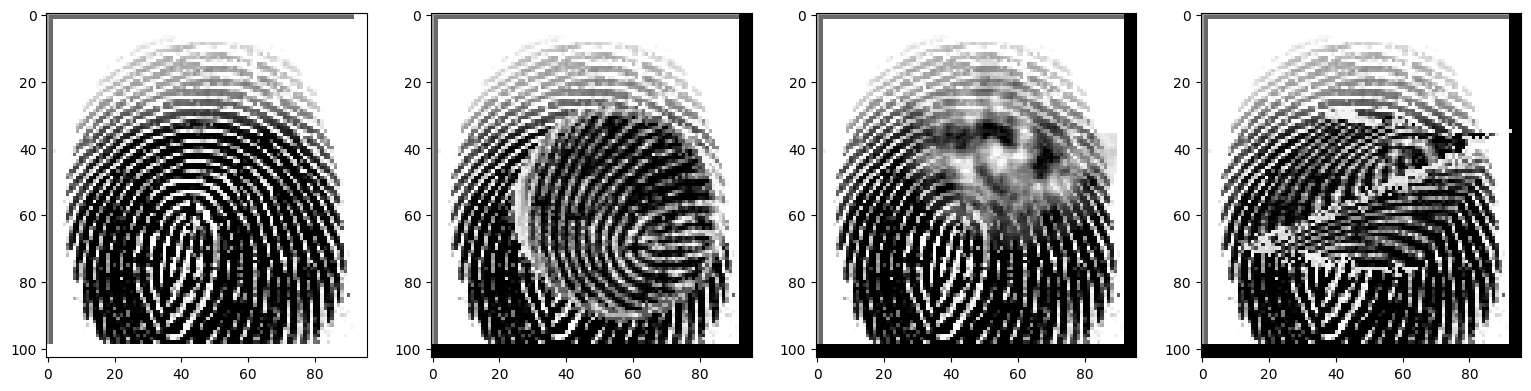

In [10]:
real_data = "./socofing/SOCOFing/Real"
altered_data = "./socofing/SOCOFing/Altered"

real_filenames = [f for f in listdir(real_data)
                  if isfile(join(real_data, f))]
digit_count = math.ceil(math.log10(len(real_filenames) + 1))

easy_filenames = [f for f in listdir(join(altered_data, "Altered-Easy"))
                  if isfile(join(altered_data, "Altered-Easy", f))]
medium_filenames = [f for f in listdir(join(altered_data, "Altered-Medium"))
                    if isfile(join(altered_data, "Altered-Medium", f))]
hard_filenames = [f for f in listdir(join(altered_data, "Altered-Hard"))
                  if isfile(join(altered_data, "Altered-Hard", f))]

print("The very listed filename: {}".format(real_filenames[0]))

real = matplotlib.image.imread(join(real_data, "1__M_Left_index_finger.BMP"))
alt_cr = matplotlib.image.imread(join(altered_data, "Altered-Hard", "1__M_Left_index_finger_CR.BMP"))
alt_obl = matplotlib.image.imread(join(altered_data, "Altered-Hard", "1__M_Left_index_finger_Obl.BMP"))
alt_zcut = matplotlib.image.imread(join(altered_data, "Altered-Hard", "1__M_Left_index_finger_Zcut.BMP"))

plt.figure()
plt.figure(figsize=(24, 25))
plt.subplot(1, 5, 1, facecolor='w')
plt.imshow(real, cmap='gray')
plt.subplot(1, 5, 2, facecolor='w')
plt.imshow(alt_cr, cmap='gray')
plt.subplot(1, 5, 3, facecolor='w')
plt.imshow(alt_obl, cmap='gray')
plt.subplot(1, 5, 4, facecolor='w')
plt.imshow(alt_zcut, cmap='gray')


In [11]:

data = []
labels = []

# load the real data and their labels

for name in real_filenames:
    data.append(cv.imread(join(real_data ,name) ,cv.IMREAD_GRAYSCALE))
    temp = name.split("_")[4]
    if temp == "index" : labels.append(0)
    elif temp == "little" : labels.append(1)
    elif temp == "middle" : labels.append(2)
    elif temp == "ring" : labels.append(3)
    else : labels.append(4)

# load the altered data and their labels
dirs = ["Altered-Easy" ,"Altered-Hard" ,"Altered-Medium"]
for folder in dirs:
    photos_names = listdir(join(altered_data ,folder))
    for name in photos_names:
        data.append(cv.imread(join(altered_data ,folder ,name) ,cv.IMREAD_GRAYSCALE))
        temp = name.split("_")[4]
        if temp == "index" : labels.append(0)
        elif temp == "little" : labels.append(1)
        elif temp == "middle" : labels.append(2)
        elif temp == "ring" : labels.append(3)
        else : labels.append(4)


In [12]:
# resizeing all the data to 103X96
for i,image in enumerate(data):
    data[i] = cv.resize(image ,(96,103))

In [13]:
for i,image in enumerate(data):
    mean = image.mean()
    std = image.std()
    image = (image.astype(np.float32) - mean)/std
    data[i] = image

# adding the gray channel
for i,image in enumerate(data):
    data[i] = image[np.newaxis,...]

In [14]:
# splitting the data
x_train_val ,x_test ,y_train_val ,y_test = train_test_split(data ,labels ,test_size=0.2 ,random_state=2509)
x_train ,x_val ,y_train ,y_val = train_test_split(x_train_val ,y_train_val ,test_size=0.125 ,random_state=2509)

In [15]:
# the hyperparameters
batch_size = 128
lr = 0.0007
weight_decay = 0.001
output_num = 5
input_shape = (103,96)
dropout_p = 0.4
epochs = 50
gamma_scheduler = 0.97
scheduler_steps = 30

# the loss function
criteria = nn.CrossEntropyLoss()

# model class
class Archit(nn.Module):

    def __init__(self ,dropout_p):
        super(Archit,self).__init__()
        #-----------------------block1---------------------------------
        self.conv1 = nn.Conv2d(1,16,(5,5),(1,1))  # 1X103X96 --> 16X99X92
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d((3,2),(2,2))   # 16X99X92  --> 16X49X46
        #-----------------------block2---------------------------------
        self.norm1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16,32,(3,3),(1,1)) # 16X49X46  --> 32X47X44
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d((3,2),(2,2))   # 32X47X44  --> 32X23X22
        self.dropout1 = nn.Dropout2d(dropout_p*0.2)
        #-----------------------block3----------------------------------
        self.norm2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32,64,(3,3),(1,1)) # 32X23X22  --> 64X21X20
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d((3,2),(2,2))   # 64X21X20  --> 64X10X10
        self.dropout2 = nn.Dropout2d(dropout_p*0.4)

        #---------------------channel attention-------------------------
        self.avg_pool = nn.AvgPool2d((10,10),1)
        self.flatten1 = nn.Flatten()
        self.norm3 = nn.BatchNorm1d(64)
        self.linear1 = nn.Linear(64,128)
        self.activ = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p*0.6)
        self.norm4 = nn.BatchNorm1d(128)
        self.linear2 = nn.Linear(128,64)
        self.sigmoid = nn.Sigmoid()
        self.dropout4 = nn.Dropout(dropout_p*0.8)
        #------------------------classifier------------------------------

        self.flatten2 = nn.Flatten()
        self.norm5 = nn.BatchNorm1d(64*10*10)
        self.linear3 = nn.Linear(64*10*10 ,5)
        self.dropout5 = nn.Dropout(dropout_p)

    def forward(self ,x):

        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.norm1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.dropout1(x)

        x = self.norm2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        x = self.dropout2(x)

        avg = self.avg_pool(x)
        avg = self.flatten1(avg)
        avg = self.norm3(avg)
        avg = self.linear1(avg)
        avg = self.activ(avg)
        avg = self.dropout3(avg)
        avg = self.norm4(avg)
        avg = self.linear2(avg)
        avg = self.sigmoid(avg)
        avg = torch.stack([avg for _ in range(100)] ,dim=-1).view(-1,64,10,10)
        atten = x * avg
        x = self.dropout4(atten)

        x = self.flatten2(x)
        x = self.norm5(x)
        x = self.linear3(x)
        x = self.dropout5(x)
        return x

# initialization of the model
model = Archit(dropout_p)

# the optimizer
optimizer = torch.optim.Adam(model.parameters() ,lr=lr ,weight_decay=weight_decay)

# learning rate scheduler
scheduler = StepLR(optimizer ,step_size=scheduler_steps ,gamma=gamma_scheduler)

In [16]:
nu_train_batches = int(np.ceil(len(x_train)/batch_size))
nu_val_batches = int(np.ceil(len(x_val)/batch_size))
nu_test_batches = int(np.ceil(len(x_test)/batch_size))

train = []
tr_label = []
val = []
val_label = []
test = []
test_label = []

pointer = 0
while nu_train_batches > 0:
    train.append(np.stack(x_train[pointer:pointer+batch_size] ,axis=0))
    tr_label.append(np.stack(y_train[pointer:pointer+batch_size] ,axis=0))
    pointer += batch_size
    nu_train_batches -= 1

pointer = 0
while nu_val_batches > 0:
    val.append(np.stack(x_val[pointer:pointer+batch_size] ,axis=0))
    val_label.append(np.stack(y_val[pointer:pointer+batch_size] ,axis=0))
    pointer += batch_size
    nu_val_batches -= 1

pointer = 0
while nu_test_batches > 0:
    test.append(np.stack(x_test[pointer:pointer+batch_size] ,axis=0))
    test_label.append(np.stack(y_test[pointer:pointer+batch_size] ,axis=0))
    pointer += batch_size
    nu_test_batches -= 1


In [17]:
patience = 15
best_loss = np.inf
accuracy_train_all = []
loss_train_all = []
accuracy_val_all = []
loss_val_all = []
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

for e in range(epochs):
    print(f"epoch : {e+1}/{epochs}")

    accuracy_train = []
    loss_train = []
    accuracy_val = []
    loss_val = []

    model.train()
    for data,labels in zip(train ,tr_label):
        data = torch.tensor(data, dtype=torch.float32).to(device)
        labels = torch.tensor(labels).to(device)
        output = model(data)
        optimizer.zero_grad()
        loss = criteria(output ,labels)
        loss.backward()
        optimizer.step()
        loss_train.append(loss.item())
        accuracy = torch.sum(torch.argmax(torch.softmax(output ,dim=-1) ,dim=-1) == labels)/len(data)
        accuracy_train.append(accuracy.item())

    loss = sum(loss_train)/len(loss_train)
    accuracy = sum(accuracy_train)/len(accuracy_train)
    loss_train_all.append(loss)
    accuracy_train_all.append(accuracy)
    print(f"train loss : {loss:.3f} ,train accuracy : {accuracy*100:.3f}% ," ,end ="")
    scheduler.step()

    model.eval()
    with torch.no_grad():

        for data,labels in zip(val ,val_label):
            data = torch.tensor(data, dtype=torch.float32).to(device)
            labels = torch.tensor(labels).to(device)
            output = model(data)
            loss = criteria(output ,labels)
            loss_val.append(loss.item())
            accuracy = torch.sum(torch.argmax(torch.softmax(output ,dim=-1) ,dim=-1) == labels)/len(data)
            accuracy_val.append(accuracy.item())

    loss = sum(loss_val)/len(loss_val)
    accuracy = sum(accuracy_val)/len(accuracy_val)
    loss_val_all.append(loss)
    accuracy_val_all.append(accuracy)
    print(f"validation loss : {loss:.3f} ,validation accuracy : {accuracy*100:.3f}%\n")

    if 0.05 < np.abs(best_loss-loss) and loss<best_loss:
        torch.save(model.state_dict(), "./model.pt")
        best_loss = loss
        patience = 15
    else:
        patience -= 1

    if patience == 0:
        print("\n\n","done".center(100,"-") ,sep="")
        break


epoch : 1/50
train loss : 1.350 ,train accuracy : 42.494% ,validation loss : 0.933 ,validation accuracy : 64.997%

epoch : 2/50
train loss : 1.202 ,train accuracy : 47.674% ,validation loss : 0.848 ,validation accuracy : 69.446%

epoch : 3/50
train loss : 1.124 ,train accuracy : 50.642% ,validation loss : 0.799 ,validation accuracy : 72.971%

epoch : 4/50
train loss : 1.064 ,train accuracy : 52.928% ,validation loss : 0.769 ,validation accuracy : 74.731%

epoch : 5/50
train loss : 1.016 ,train accuracy : 54.955% ,validation loss : 0.715 ,validation accuracy : 77.953%

epoch : 6/50
train loss : 0.974 ,train accuracy : 57.092% ,validation loss : 0.691 ,validation accuracy : 80.180%

epoch : 7/50
train loss : 0.939 ,train accuracy : 58.340% ,validation loss : 0.640 ,validation accuracy : 81.664%

epoch : 8/50
train loss : 0.907 ,train accuracy : 59.872% ,validation loss : 0.606 ,validation accuracy : 84.604%

epoch : 9/50
train loss : 0.890 ,train accuracy : 60.692% ,validation loss : 0.6

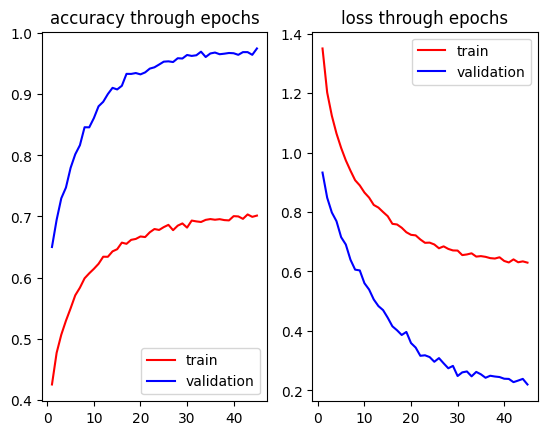

In [18]:
figure, axis = plt.subplots(1, 2) 
x = np.arange(1,e+2)

y = np.array(accuracy_train_all)
axis[0].plot(x,y ,color="red" ,label="train")
y = np.array(accuracy_val_all)
axis[0].plot(x,y ,color="blue" ,label="validation")
axis[0].set_title("accuracy through epochs")
axis[0].legend() 

y = np.array(loss_train_all)
axis[1].plot(x,y ,color="red" ,label="train")
y = np.array(loss_val_all)
axis[1].plot(x,y ,color="blue" ,label="validation")
axis[1].set_title("loss through epochs")
axis[1].legend() 
plt.show()


In [22]:
train_loss = []
train_accuracy = []
model.eval()
model.to(device)
with torch.no_grad():     
    for data,labels in zip(test ,test_label):
        data = torch.tensor(data,dtype=torch.float32).to(device)
        labels = torch.tensor(labels).to(device)
        output = model(data)
        loss = criteria(output ,labels)
        train_loss.append(loss.item())
        accuracy = torch.sum(torch.argmax(torch.softmax(output ,dim=-1) ,dim=-1) == labels)/len(data)
        train_accuracy.append(accuracy.item())
    
loss = sum(train_loss)/len(train_loss)
accuracy = sum(train_accuracy)/len(train_accuracy)
print(f"test loss : {loss:.3f} ,test accuracy : {accuracy*100:.3f}%\n")


test loss : 0.225 ,test accuracy : 96.931%



In [36]:
class Archit(nn.Module):
    
    def __init__(self ,dropout_p):
        super(Archit,self).__init__()
        #-----------------------block1---------------------------------
        self.conv1 = nn.Conv2d(1,16,(5,5),(1,1))  # 1X103X96 --> 16X99X92
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d((3,2),(2,2))   # 16X99X92  --> 16X49X46
        #-----------------------block2---------------------------------
        self.norm1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16,32,(3,3),(1,1)) # 16X49X46  --> 32X47X44
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d((3,2),(2,2))   # 32X47X44  --> 32X23X22
        self.dropout1 = nn.Dropout2d(dropout_p*0.2)
        #-----------------------block3----------------------------------
        self.norm2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32,64,(3,3),(1,1)) # 32X23X22  --> 64X21X20
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d((3,2),(2,2))   # 64X21X20  --> 64X10X10
        self.dropout2 = nn.Dropout2d(dropout_p*0.4)
        
        #---------------------channel attention-------------------------
        self.avg_pool = nn.AvgPool2d((10,10),1)
        self.flatten1 = nn.Flatten()
        self.norm3 = nn.BatchNorm1d(64)
        self.linear1 = nn.Linear(64,128)
        self.activ = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p*0.6)
        self.norm4 = nn.BatchNorm1d(128)
        self.linear2 = nn.Linear(128,64)
        self.sigmoid = nn.Sigmoid()
        self.dropout4 = nn.Dropout(dropout_p*0.8)
        #------------------------classifier------------------------------
        
        self.flatten2 = nn.Flatten()
        self.norm5 = nn.BatchNorm1d(64*10*10)
        self.linear3 = nn.Linear(64*10*10 ,5)
        self.dropout5 = nn.Dropout(dropout_p)
        
    def forward(self ,x):
        
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        x = self.norm1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.dropout1(x)
        
        x = self.norm2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        x = self.dropout2(x)
        
        avg = self.avg_pool(x)
        avg = self.flatten1(avg)
        avg = self.norm3(avg)
        avg = self.linear1(avg)
        avg = self.activ(avg)
        avg = self.dropout3(avg)
        avg = self.norm4(avg)
        avg = self.linear2(avg)
        avg = self.sigmoid(avg)
        avg = torch.stack([avg for _ in range(100)] ,dim=-1).view(-1,64,10,10)
        atten = x * avg
        x = self.dropout4(atten)
        
        y = self.flatten2(x)
        
        x = self.norm5(y)
        x = self.linear3(x)
        x = self.dropout5(x)
        return x,y
    
saved_model = "model.pt"
model = Archit(dropout_p)
model.load_state_dict(torch.load(saved_model))
model.to(device)
model.eval()


Archit(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=(3, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (norm1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=(3, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.08000000000000002, inplace=False)
  (norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=(3, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.16000000000000003, inplace=False)
  (avg_pool): AvgPool2d(kernel_size=(10, 10), stride=1, padding=0)
  (flatten1): Flatten(start_dim=1, end_dim=-1)
  (norm3): BatchNorm1d(64, eps=1e-05, momentum=0

In [25]:
import os

easy_thresholds = []
medium_thresholds = []
hard_thresholds = []

# load the real data and their labels
# key:value ---> participant_id:{0:data,...}
photos_names = os.listdir(real_data)
real = {i:{j:None for j in range(5)} for i in range(1,600+1)} 
for name in photos_names:
    label = None
    data = cv.imread(os.path.join(real_data ,name) ,cv.IMREAD_GRAYSCALE)
    data = cv.resize(data ,(96,103))
    mean = data.mean()
    std = data.std()
    data = (data.astype(np.float32) - mean)/std
    data = torch.tensor(data[np.newaxis,np.newaxis,...],dtype=torch.float32)
    temp = name.split("_")
    if temp[4] == "index" : label = 0
    elif temp[4] == "little" : label = 1
    elif temp[4] == "middle" : label = 2
    elif temp[4] == "ring" : label = 3
    else : label = 4
    real[int(temp[0])][label] = data 

# load the altered data and their labels
dirs = ["Altered-Easy" ,"Altered-Hard" ,"Altered-Medium"]
for folder in dirs:
    altered = [] # every photo will be in tuple : (participant_id ,photo ,label)
    photos_names = os.listdir(os.path.join(altered_data ,folder))
    for name in photos_names:
        label = None
        data = cv.imread(os.path.join(altered_data ,folder ,name) ,cv.IMREAD_GRAYSCALE)
        data = cv.resize(data ,(96,103))
        mean = data.mean()
        std = data.std()
        data = (data.astype(np.float32) - mean)/std
        data = torch.tensor(data[np.newaxis,np.newaxis,...],dtype=torch.float32)
        temp = name.split("_")
        if temp[4] == "index" : label = 0
        elif temp[4] == "little" : label = 1
        elif temp[4] == "middle" : label = 2
        elif temp[4] == "ring" : label = 3
        else : label = 4
        altered.append((int(temp[0]) ,data ,label))
    for item in altered:
        participant_id = item[0]
        data = item[1].to(device)
        label = item[2]
        alter_out = model(data)[1]
        real_out = model(real[participant_id][label].to(device))[1]
        threshold = torch.pow(alter_out - real_out ,2).sum().sqrt().item()
        if folder == "Altered-Easy" : easy_thresholds.append(threshold)
        elif folder == "Altered-Medium" : medium_thresholds.append(threshold)
        else : hard_thresholds.append(threshold)


In [26]:
easy = np.mean(easy_thresholds)
medium = np.mean(medium_thresholds)
hard = np.mean(hard_thresholds)
final = np.mean(
    [np.min(easy_thresholds) ,np.min(medium_thresholds) ,np.min(hard_thresholds)])
print(f"final threshold is {final:.5f}")


final threshold is 0.39450


In [73]:

class InferenceArchitect:
    
    def __init__(self ,model):
        self.model = model.eval()
        self.threshold = 0.39450
        self.transforms = nn.Sequential(T.Resize([103,96]),
                                        T.ConvertImageDtype(torch.float),
                                        T.Normalize([0.5],[0.5]))
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self ,image ,mode=True ,ids=None):
        # image as numpy 4-D tensor (batch_size ,1 ,height ,width)
        image = torch.tensor(image)
        image = image/255
        image = self.transforms(image)
        if mode: # means extracing feature vector and saving it with the ids given
            if not ids : print("ids is not provided !!")
            if len(ids) != image.shape[0] : print("mismatched number of ids !!")
            with torch.no_grad():
                output,feature = self.model(image.to(device))
                output = self.softmax(output)
                labels = torch.argmax(output ,dim=-1)
            for i in range(image.shape[0]):
                if torch.max(output[i]) >= 0.7:
                    path = os.path.join(os.getcwd() ,str(ids[i]) 
                                        ,str(labels[i].item())+".pt")
                    if os.path.isfile(path):
                        print(f"id alraedy exsist !! : {path}")
                    else:
                        torch.save(feature ,path)
                else:
                    print(f"image #{i+1} can't be classified")
        else:
            with torch.no_grad():
                output,feature = self.model(image)
                output = self.softmax(output)
                print(output)
                labels = torch.argmax(output ,dim=-1)
            ids = os.listdir(os.getcwd())
            for i in range(image.shape[0]):
                possible = []
                if torch.max(output[i]) >= 0.7:
                    for j in ids:
                        if not j.endswith(".pt"): continue
                        # torch.serialization.add_safe_globals([DetectionModel])
                        data = torch.load(os.path.join(os.getcwd() ,j),weights_only=False)
                        try:
                            threshold = torch.pow(data-output[i],2).sum().sqrt().item()
                            if threshold <= self.threshold: 
                                possible.append((threshold ,j))
                        except:
                            pass
                        
                else:
                    print(f"image #{i+1} can't be classified")
                if possible:
                    temp = possible[2][0]
                    if temp == '0' : temp = "index" 
                    elif temp == '1' : temp = "little" 
                    elif temp == '2' : temp = "middle"  
                    elif temp == '3' : temp = "ring" 
                    else : temp = "thumb"
                    print(f"id {possible[1]} and file name {possible[2]}"
                          f"which represent {temp}")
                else:
                    print(f"image #{i+1} can't be don't exsist yet !!")

In [38]:
model

Archit(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=(3, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (norm1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=(3, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.08000000000000002, inplace=False)
  (norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=(3, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.16000000000000003, inplace=False)
  (avg_pool): AvgPool2d(kernel_size=(10, 10), stride=1, padding=0)
  (flatten1): Flatten(start_dim=1, end_dim=-1)
  (norm3): BatchNorm1d(64, eps=1e-05, momentum=0

In [74]:
from PIL import Image


result=InferenceArchitect(model)
image_path="C:/Users\\USER\\Downloads\\archive\\test_2.BMP"
img = Image.open(image_path).convert('L')
img_np = np.array(img, dtype=np.float32)  
img_4d = np.expand_dims(img_np, axis=(0, 1))
result.forward(img_4d,False)



tensor([[0.0201, 0.0402, 0.0917, 0.8372, 0.0108]])


ModuleNotFoundError: No module named 'ultralytics'

In [68]:
!pip install ultralytics

In [ ]:
!